#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº3
#### Nicolas Bravo

# Introducción

En este informe se va a trabajar sobre el fenómeno del derrame espectral propio de la DFT. Este fenómeno ocurre cuando se calcula la transformada discreta de Fourier de una señal periódica la cual no tiene una cantidad de ciclos enteros en el intervalo de análisis. Este fenómeno ocurre porque al analizar una señal, lo que se hace realmente es observar una señal infinita a través de una ventana rectangular y, al calcular su transformada, se convoluciona el espectro de la señal con una *sinc*. Si la frecuencia de la señal coincide con un bin ($k = \dfrac{N}{f_s}$), los ceros de la *sinc* coinciden con el resto de los bins de la DFT, pero si la frecuencia no coincide con ninguno de los bins, ningún cero coincide con los bins vecinos y la energía de la señal se derrama sobre todo el espectro.

Luego se va a demostrar este efecto aplicando la técnica del *zero padding* el cual aumenta artificialmente la resolución espectral sin agregar información a la señal agregando ceros al final de la ventana de muestreo.

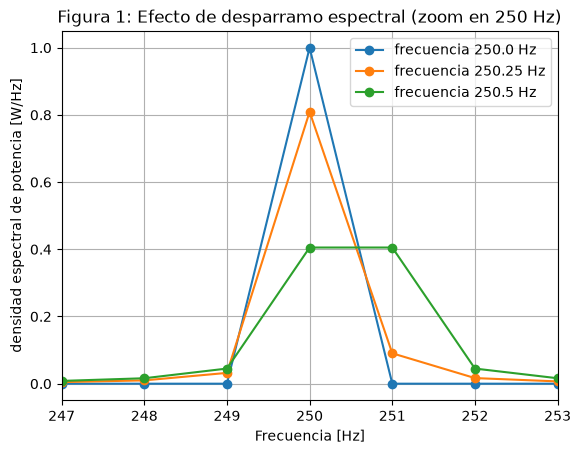

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as scp
#%%

N = 1000 #[muestras]  Cant de muestras
fs = 1000 #[Hz]       Frecuencia de muestras // Variar
pot_in = 2              #[W] Potencia de la señal
vmax = np.sqrt(2)        #[volts]
dc = 0      #[volts]

ph = 0      #[rad]
ph2 = np.pi/2
nn = N      #[muestras]
fs = fs         #[Hz]
k = [N//4, N//4 +0.25, N/4 +0.5]
#%%

def mi_funcion_sen (vmax, dc, ff, ph, nn, fs):
    
    tt = np.arange(start=0, stop=nn/fs, step=1/fs)
    xx = vmax*np.sin(2*np.pi * ff * tt + ph) + dc
    
    return (tt, xx)

def zero_padding(xx, factor = 10):
    len_pad = factor*len(xx)
    sign_pad = np.zeros(len_pad, dtype=float)
    sign_pad[:len(xx)] = xx
    return(sign_pad, len_pad)
    
#%%

ff1 = k[0] * fs / N
tt, xx = mi_funcion_sen(vmax, dc, ff1, ph, nn, fs)

frec = np.arange(start=0,step=fs,stop=fs*N)/N
xxf = np.abs(np.fft.fft(xx)/N)

#%% k = 0.25
ff2 = k[1] * fs / N
tt, xx2 = mi_funcion_sen(vmax, dc, ff2, ph, nn, fs)
xxf2 = np.abs(np.fft.fft(xx2)/N)

#%% k = 0.5
ff3 = k[2] * fs / N
tt, xx3 = mi_funcion_sen(vmax, dc, ff3, ph, nn, fs)
xxf3 = np.abs(np.fft.fft(xx3)/N)

#%% PSD
plt.figure()
psd1 = xxf**2*2
psd1 = psd1[:N//2]
plt.plot(frec[:N//2], psd1, '-o', label=f"frecuencia {k[0] * fs / N} Hz")
psd2 = xxf2**2*2
psd2 = psd2[:N//2]
plt.plot(frec[:N//2], psd2, '-o', label=f"frecuencia {k[1] * fs / N} Hz")
psd3 = xxf3**2*2
psd3 = psd3[:N//2]
plt.plot(frec[:N//2], psd3, '-o', label=f"frecuencia {k[2] * fs / N} Hz")
plt.xlim(247, 253)
plt.grid()
plt.legend(loc = 'upper right');
plt.ylabel("densidad espectral de potencia [W/Hz]");
plt.xlabel("Frecuencia [Hz]");
plt.title("Figura 1: Efecto de desparramo espectral (zoom en 250 Hz)");

Se puede apreciar que en la figura 1 como afecta la diferencia entre señales con frecuencias que coinciden con bins y las que no. En la que la frecuencia coincide con un bin, toda la energía está concentrada en la frecuencia de 250Hz mientras que la frecuencia que se encuentra en 250.25Hz tiene su mayor valor en 250Hz ya que es el bin más cercano mientras que el sobrante de energía se distribuye entre los demás bins. En la frecuencia de 250.5Hz la energía se distribuye en partes iguales entre los dos bins más cercanos ya que están a la misma distancia y en los demás bins se distribuye la energía sobrante.

In [2]:
pars1 = 1/N * np.sum(xx**2)
pars12 =  np.sum(xxf**2)
pars2 = 1/N * np.sum(xx2**2)
pars22 =  np.sum(xxf2**2)
pars3 = 1/N * np.sum(xx3**2)
pars32 =  np.sum(xxf3**2)
print(f"potencia de señal de frecuencia {ff1}Hz = {pars1:.2F} y potencia de PSD = {pars12:.2F}")
print(f"potencia de señal de frecuencia {ff2}Hz = {pars2:.2F} y potencia de PSD = {pars22:.2F}")
print(f"potencia de señal de frecuencia {ff3}Hz = {pars3:.2F} y potencia de PSD = {pars32:.2F}")

potencia de señal de frecuencia 250.0Hz = 1.00 y potencia de PSD = 1.00
potencia de señal de frecuencia 250.25Hz = 1.00 y potencia de PSD = 1.00
potencia de señal de frecuencia 250.5Hz = 1.00 y potencia de PSD = 1.00


Utilizando el Teorema de Parseval podemos ver que la potencia de la señal se conserva distribuida entre bins y que el desparramo no es una perdida real de energía.

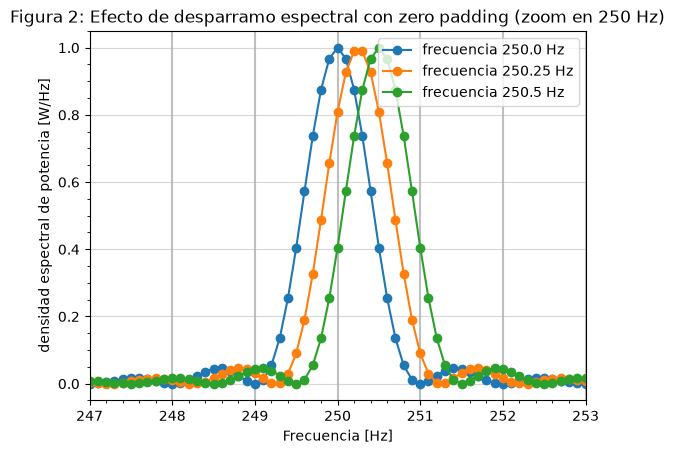

In [3]:
#%% zero padding
plt.figure()
#%% 250
xxw, N_new = zero_padding(xx, 10)

xxfw = np.abs(np.fft.fft(xxw)/N)
frecw = np.arange(start=0,step=fs,stop=fs*N_new)/N_new

psdw1 = xxfw**2*2
psdw1 = psdw1[:N_new//2]
plt.plot(frecw[:N_new//2], psdw1, '-o', label=f"frecuencia {k[0] * fs / N} Hz")
#%% 250.25
xxw2, N_new = zero_padding(xx2, 10)

xxfw2 = np.abs(np.fft.fft(xxw2)/N)

psdw2 = xxfw2**2*2
psdw2 = psdw2[:N_new//2]
plt.plot(frecw[:N_new//2], psdw2, '-o', label=f"frecuencia {k[1] * fs / N} Hz")
#%% 250.5
xxw3, N_new = zero_padding(xx3, 10)

xxfw3 = np.abs(np.fft.fft(xxw3)/N)

psdw3 = xxfw3**2*2
psdw3 = psdw3[:N_new//2]
plt.plot(frecw[:N_new//2], psdw3, '-o', label=f"frecuencia {k[2] * fs / N} Hz")
plt.xlim(247, 253)
plt.minorticks_on()
plt.xticks([247, 248, 249, 250, 251, 252, 253])
plt.grid(axis='x', which='major', linewidth=1.5, alpha=0.8)
plt.grid(axis='y', which='major', linewidth=0.8, alpha=0.5)
plt.legend(loc = 'upper right')
plt.ylabel("densidad espectral de potencia [W/Hz]")
plt.xlabel("Frecuencia [Hz]")
plt.title("Figura 2: Efecto de desparramo espectral con zero padding (zoom en 250 Hz)");

Al agregar 9N ceros al final de la señal, la densidad espectral se vuelve más fina y asi podemos apreciar con mayor claridad la *sinc* procedente de la transformada de la ventana de muestreo.

In [4]:
pars1 = 1/N * np.sum(xxw**2)
pars12 =  np.sum(xxfw**2)
pars2 = 1/N * np.sum(xxw2**2)
pars22 =  np.sum(xxfw2**2)
pars3 = 1/N * np.sum(xxw3**2)
pars32 = np.sum(xxfw3**2) 
print(f"potencia de señal de frecuencia {ff1}Hz = {pars1:.2F} y potencia de PSD = {pars12:.2F}")
print(f"potencia de señal de frecuencia {ff2}Hz = {pars2:.2F} y potencia de PSD = {pars22:.2F}")
print(f"potencia de señal de frecuencia {ff3}Hz = {pars3:.2F} y potencia de PSD = {pars32:.2F}")

potencia de señal de frecuencia 250.0Hz = 1.00 y potencia de PSD = 10.00
potencia de señal de frecuencia 250.25Hz = 1.00 y potencia de PSD = 9.99
potencia de señal de frecuencia 250.5Hz = 1.00 y potencia de PSD = 10.00


Por último se puede notar que la potencia de la señal no varía si utilizamos el *zero padding* ya que este no agrega valores pero si aumenta en factor de 10 al usar 10 veces más muestras.